# Chapter 3 — Signals, Noise & the Radiometer Equation

!!! info "Before you start"
    **Prerequisites:** Ch 2 (The Physics of Radio Emission) · **Maths Lab:** [Lab C (Noise Statistics & RFI Excision)](33_mathslab_noise_rfi.ipynb) · **~45 min** · **Beginner**

In [Chapter 1](01_what_is_radio_astronomy.ipynb) we met radio waves from space, and in
[Chapter 2](02_physics_of_radio_emission.ipynb) we learned to speak of radio brightness in
**temperature** units. That choice of units is about to pay off. A radio telescope is, at
its heart, *an exquisitely sensitive thermometer*: it does not "see" a source so much as
measure a tiny rise in temperature against a roaring background of noise.

The trouble is that the noise is **huge**. The faint hiss from a distant galaxy can be ten
thousand times weaker than the noise generated inside the receiver itself. So how does
anyone ever detect anything? The answer — and the single most important equation in
observational radio astronomy — is the **radiometer equation**. It tells us that noise is
not a wall but a *fog that thins out* the longer we look and the wider a band we record.
Patience, quantified.

## What you'll learn

- What **system temperature** $T_\mathrm{sys}$ and **antenna temperature** $T_A$ mean, and
  why we add up every noise contribution into one number.
- How to **derive and justify the radiometer equation**
  $\;\Delta T = T_\mathrm{sys} / \sqrt{n_\mathrm{pol}\, B\, \tau}\;$
  from the statistics of averaging.
- That sensitivity improves only as the **square root** of bandwidth $\times$ integration
  time — so to double your sensitivity you must observe *four times* as long.
- To **watch a faint source emerge from the noise** in a Monte-Carlo simulation, and check
  that the empirical scatter matches the equation's prediction to the decimal.
- Why Robert Dicke **switched** his receiver against a reference load — the trick that made
  microwave radiometry practical and later helped find the cosmic microwave background.

## The paper: Dicke (1946)

> **Dicke, R. H. (1946).** *The Measurement of Thermal Radiation at Microwave Frequencies.*
> Review of Scientific Instruments **17**, 268.
> [DOI: 10.1063/1.1770483](https://doi.org/10.1063/1.1770483)

During the Second World War, Robert Dicke worked at the MIT Radiation Laboratory on
microwave radar. He realised that the same receivers could be turned skyward to measure the
faint **thermal radiation** of the atmosphere, the Sun, and the Moon — if only you could tame
the noise. His 1946 paper laid out two ideas that still govern every radio telescope built
since:

1. **The radiometer equation.** Dicke showed that the smallest detectable change in input
   temperature, $\Delta T$, falls as the square root of the **bandwidth** $B$ times the
   **integration time** $\tau$:
   $$ \Delta T \;\sim\; \frac{T_\mathrm{sys}}{\sqrt{B\,\tau}}. $$
   You beat noise by collecting more *independent samples* of it — and a receiver of
   bandwidth $B$ delivers about $2B$ independent samples per second.

2. **The Dicke switch.** Real receivers don't have a constant gain; it drifts slowly (so-called
   $1/f$ noise). Dicke beat the drift by rapidly switching the receiver between the sky and a
   stable **reference load**, and looking only at the *difference*. Common-mode gain
   wandering cancels out. This "Dicke radiometer" is why microwave radiometry — and, two
   decades later, [Penzias & Wilson's discovery of the
   CMB](https://doi.org/10.1086/148307) — became possible.

With his receiver Dicke even placed an upper limit on the temperature of any cosmic microwave
background of "less than 20 K" — astonishingly, a near-miss on the 2.7 K signal that would
make Penzias and Wilson famous in 1965. The instrument that found the echo of the Big Bang
was, in essence, a Dicke radiometer.

## The physics

### Everything is a temperature

A resistor at physical temperature $T$ delivers thermal-noise power $P = k_B T B$ into a
matched load over bandwidth $B$ (this is **Johnson–Nyquist noise**; $k_B$ is Boltzmann's
constant). A radio receiver can't tell the difference between that resistor and the sky:
both look like a source of random, band-limited noise. So radio astronomers describe *every*
noise contribution by the temperature of the equivalent resistor that would produce it.

The **antenna temperature** $T_A$ is the apparent temperature due to the astronomical
signal collected by the antenna. The **system temperature** $T_\mathrm{sys}$ is the sum of
*everything* the receiver sees:

$$ T_\mathrm{sys} \;=\; T_\mathrm{rx} \;+\; T_\mathrm{sky} \;+\; T_\mathrm{spill}
   \;+\; T_\mathrm{CMB} \;+\; T_A \;+\; \dots $$

with contributions from the receiver electronics ($T_\mathrm{rx}$), atmospheric/galactic
emission ($T_\mathrm{sky}$), ground spillover into the sidelobes ($T_\mathrm{spill}$), the
2.7 K cosmic microwave background, and the source itself. For a faint source
$T_A \ll T_\mathrm{sys}$, and the whole game is to measure that small bump on top of a large,
*noisy* pedestal.

### Why averaging helps: the radiometer equation

The receiver output is a noise voltage. Square-law detect it and you get a power proportional
to temperature, but with **fluctuations of order the mean** — a single instantaneous sample
of $T_\mathrm{sys}$ tells you almost nothing. The cure is to average many *independent*
samples.

A signal of bandwidth $B$ decorrelates on a timescale $\sim 1/B$ (the Nyquist sampling
interval), so an integration of length $\tau$ contains roughly

$$ N \;\approx\; B\,\tau $$

independent samples (more precisely $2B\tau$ real samples, with a factor that gets absorbed
into convention). The standard error of the mean of $N$ independent samples falls as
$1/\sqrt{N}$. Each sample has a scatter $\sim T_\mathrm{sys}$, so the uncertainty on the
*averaged* temperature is

$$ \boxed{\;\Delta T \;=\; \dfrac{T_\mathrm{sys}}{\sqrt{n_\mathrm{pol}\, B\, \tau}}\;} $$

This is the **radiometer equation**. The factor $n_\mathrm{pol}$ accounts for averaging both
hands of polarisation: an unpolarised source carries independent noise in each, so using both
buys another factor of $\sqrt{2}$ in sensitivity.

### The square-root law has teeth

Because $\Delta T \propto (B\tau)^{-1/2}$, sensitivity improves *slowly*:

- To make the noise **2× smaller**, you need **4× more** integration time (or bandwidth).
- To make it **10× smaller**, you need **100× more**.

That square root is the central economic fact of radio astronomy: deep observations cost
*quadratically* in telescope time. The detectability of a source is set by its
**signal-to-noise ratio**, $\mathrm{S/N} = T_A / \Delta T$, and a detection conventionally
requires $\mathrm{S/N} \gtrsim 5$.

## Setting up

We'll lean on three helpers from `jansky.signals`:

- `radiometer_sensitivity(t_sys, bandwidth, integration_time, n_pol)` — evaluates
  $\Delta T = T_\mathrm{sys}/\sqrt{n_\mathrm{pol}\,B\,\tau}$ directly.
- `integrate_noise(...)` — Monte-Carlo simulates a running integration and returns the
  running estimate alongside the theoretical $\pm\sigma$ envelope.
- `rng(seed)` — a seeded NumPy generator so every figure is reproducible.

We seed all randomness and call `plotting.use_jansky_style()` so the figures match the rest
of the course.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.constants import k_B

from jansky import signals, plotting

plotting.use_jansky_style()

# One global seed for the whole notebook, for reproducibility.
SEED = 1946  # the year of Dicke's paper
np.random.seed(SEED)

print(f"Boltzmann constant k_B = {k_B:.4e}")

Boltzmann constant k_B = 1.3806e-23 J / K


### A sanity check on the units

Before trusting any equation, it's worth confirming the temperature picture with real units.
A resistor (or the sky) at temperature $T$ delivers noise power $P = k_B T B$. Let's see how
much power a typical system temperature of 30 K dumps into a 1 MHz band — and confirm it is a
*minuscule* amount, which is exactly why radio receivers are such delicate instruments.

In [2]:
T_sys = 30 * u.K  # a good modern cryogenic receiver
B = 1 * u.MHz  # 1 MHz of bandwidth

P_noise = (k_B * T_sys * B).to(u.W)
print(f"Noise power in {B:.0f} from a {T_sys:.0f} system: {P_noise:.3e}")
print(
    f"That is {P_noise.to(u.W).value:.2e} W -- about {(P_noise / (1e-3 * u.W)).to(u.dimensionless_unscaled):.2e} of a milliwatt."
)

Noise power in 1 MHz from a 30 K system: 4.142e-16 W
That is 4.14e-16 W -- about 4.14e-13 of a milliwatt.


## The square-root law, plotted

Let's evaluate the radiometer equation across a range of integration times and bandwidths and
plot it on **log–log axes**, where a power law $\Delta T \propto x^{-1/2}$ becomes a straight
line of slope $-1/2$.

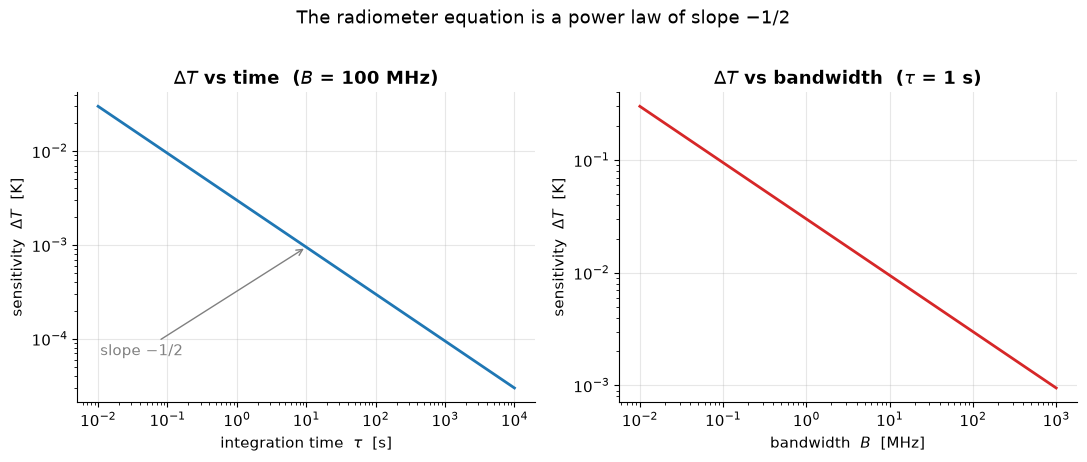

In [3]:
T_sys = 30.0  # K
B_fixed = 100e6  # 100 MHz reference bandwidth
tau_fixed = 1.0  # 1 s reference integration

# Sweep integration time at fixed bandwidth.
taus = np.logspace(-2, 4, 200)  # 0.01 s -> 10000 s
dT_vs_tau = signals.radiometer_sensitivity(T_sys, B_fixed, taus)

# Sweep bandwidth at fixed integration time.
bandwidths = np.logspace(4, 9, 200)  # 10 kHz -> 1 GHz
dT_vs_B = signals.radiometer_sensitivity(T_sys, bandwidths, tau_fixed)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.loglog(taus, dT_vs_tau, color="#1f77b4", lw=2)
ax1.set_xlabel(r"integration time  $\tau$  [s]")
ax1.set_ylabel(r"sensitivity  $\Delta T$  [K]")
ax1.set_title(f"$\\Delta T$ vs time  ($B$ = {B_fixed / 1e6:.0f} MHz)")

ax2.loglog(bandwidths / 1e6, dT_vs_B, color="#d62728", lw=2)
ax2.set_xlabel(r"bandwidth  $B$  [MHz]")
ax2.set_ylabel(r"sensitivity  $\Delta T$  [K]")
ax2.set_title(rf"$\Delta T$ vs bandwidth  ($\tau$ = {tau_fixed:.0f} s)")

# Annotate the -1/2 slope on the time panel with a reference triangle.
ax1.annotate(
    "slope $-1/2$",
    xy=(10, signals.radiometer_sensitivity(T_sys, B_fixed, 10)),
    xytext=(0.05, 0.15),
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", color="gray"),
    color="gray",
)

fig.suptitle("The radiometer equation is a power law of slope $-1/2$", y=1.02)
fig.tight_layout()
plt.show()

Both panels are dead-straight lines with slope $-\tfrac12$. Notice the consequence on the
left panel: going from $\tau = 1$ s to $\tau = 10{,}000$ s — about three hours — only buys a
factor of $\sqrt{10^4} = 100$ in sensitivity. The longest tracks on the biggest telescopes
are an expensive way to chase that square root.

### Verifying the scaling numerically

Let's not just *look* like slope $-1/2$ — let's prove it. The radiometer equation predicts
that quadrupling the integration time should improve $\Delta T$ by exactly a factor of two.

In [4]:
T_sys, B = 30.0, 100e6

dT_1s = signals.radiometer_sensitivity(T_sys, B, 1.0)
dT_4s = signals.radiometer_sensitivity(T_sys, B, 4.0)
dT_100s = signals.radiometer_sensitivity(T_sys, B, 100.0)

print(f"dT(1 s)   = {dT_1s * 1e3:.4f} mK")
print(f"dT(4 s)   = {dT_4s * 1e3:.4f} mK")
print(f"dT(100 s) = {dT_100s * 1e3:.4f} mK")
print()
print(f"  4x time  -> improvement factor = {dT_1s / dT_4s:.4f}   (expect 2.0)")
print(f"100x time  -> improvement factor = {dT_1s / dT_100s:.4f}  (expect 10.0)")

# Fit the log-log slope to confirm the exponent is -1/2.
taus = np.logspace(-2, 4, 200)
slope = np.polyfit(np.log(taus), np.log(signals.radiometer_sensitivity(T_sys, B, taus)), 1)[0]
print(f"\nfitted log-log slope = {slope:.4f}   (expect -0.5)")

assert np.isclose(dT_1s / dT_4s, 2.0)
assert np.isclose(slope, -0.5, atol=1e-6)
print("\nScaling verified.")

dT(1 s)   = 3.0000 mK
dT(4 s)   = 1.5000 mK
dT(100 s) = 0.3000 mK

  4x time  -> improvement factor = 2.0000   (expect 2.0)
100x time  -> improvement factor = 10.0000  (expect 10.0)

fitted log-log slope = -0.5000   (expect -0.5)

Scaling verified.


The numbers come out exactly as predicted: 4× time gives precisely 2× the sensitivity, 100×
time gives 10×, and the fitted slope is $-0.5000$. Polarisation gives a smaller, fixed boost
— let's confirm the $\sqrt{2}$:

In [5]:
dT_1pol = signals.radiometer_sensitivity(T_sys, B, 1.0, n_pol=1)
dT_2pol = signals.radiometer_sensitivity(T_sys, B, 1.0, n_pol=2)
print(f"single polarisation: dT = {dT_1pol * 1e3:.4f} mK")
print(f"dual   polarisation: dT = {dT_2pol * 1e3:.4f} mK")
print(f"improvement factor = {dT_1pol / dT_2pol:.4f}   (expect sqrt(2) = {np.sqrt(2):.4f})")

single polarisation: dT = 3.0000 mK
dual   polarisation: dT = 2.1213 mK
improvement factor = 1.4142   (expect sqrt(2) = 1.4142)


## Watching a source climb out of the noise

This is the moment the radiometer equation becomes visceral. We'll plant a faint source —
antenna temperature $T_A = 0.05$ K — on top of a $T_\mathrm{sys} = 30$ K system, a
signal-to-noise of essentially *nothing* in a single sample. Then we integrate, and watch
the running estimate spiral inward toward the true value.

`integrate_noise` returns a `RadiometerResult` with:

- `times` — cumulative integration time at each step,
- `estimate` — the running mean of the (signal + noise) samples,
- `expected_sigma` — the radiometer-equation prediction $\Delta T(\tau)$ at each time.

We overlay the $\pm\sigma$ envelope so we can check that the wiggling estimate stays inside it
about 68% of the time, exactly as Gaussian statistics demand.

In [6]:
T_sys = 30.0  # K
B = 1e6  # 1 MHz channel
true_signal = 0.05  # K  -- the faint source we are trying to recover
total_time = 100.0  # s

result = signals.integrate_noise(
    t_sys=T_sys,
    bandwidth=B,
    total_time=total_time,
    signal=true_signal,
    n_samples=2000,
    seed=SEED,
)

# Single-sample sensitivity vs final sensitivity: the dynamic range we buy.
dt_step = result.times[0]
single = signals.radiometer_sensitivity(T_sys, B, dt_step)
final = result.expected_sigma[-1]
print(
    f"per-sample noise (dt = {dt_step * 1e3:.1f} ms): {single * 1e3:.1f} mK  "
    f"(S/N = {true_signal / single:.3f})"
)
print(
    f"final noise after {total_time:.0f} s:        {final * 1e3:.1f} mK  "
    f"(S/N = {true_signal / final:.1f})"
)

per-sample noise (dt = 50.0 ms): 134.2 mK  (S/N = 0.373)
final noise after 100 s:        3.0 mK  (S/N = 16.7)


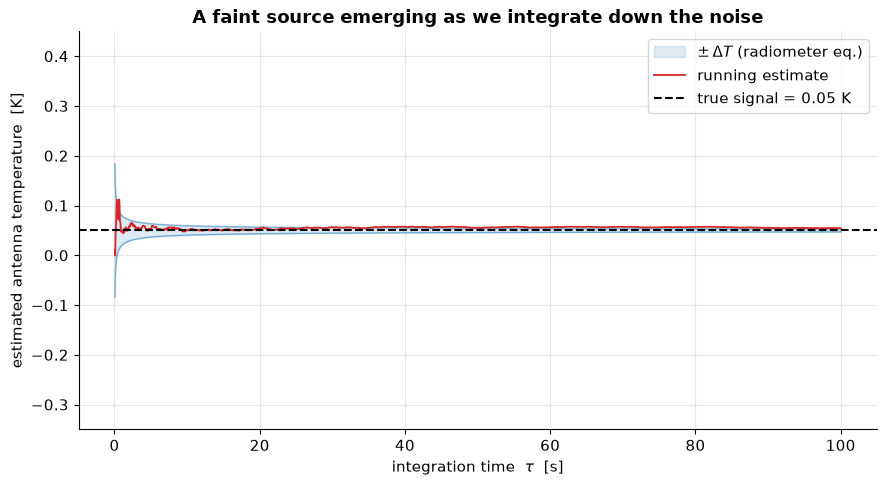

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

# The +/- expected-sigma envelope from the radiometer equation, centred on truth.
ax.fill_between(
    result.times,
    true_signal - result.expected_sigma,
    true_signal + result.expected_sigma,
    color="#1f77b4",
    alpha=0.15,
    label=r"$\pm\,\Delta T$ (radiometer eq.)",
)
ax.plot(result.times, true_signal + result.expected_sigma, color="#1f77b4", lw=1, alpha=0.5)
ax.plot(result.times, true_signal - result.expected_sigma, color="#1f77b4", lw=1, alpha=0.5)

# The running estimate spiralling in.
ax.plot(result.times, result.estimate, color="#d62728", lw=1.3, label="running estimate")

# The truth we are trying to recover.
ax.axhline(true_signal, color="k", ls="--", lw=1.5, label=f"true signal = {true_signal:.2f} K")

ax.set_xlabel(r"integration time  $\tau$  [s]")
ax.set_ylabel("estimated antenna temperature  [K]")
ax.set_title("A faint source emerging as we integrate down the noise")
ax.set_ylim(true_signal - 0.4, true_signal + 0.4)
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

At first the estimate flails wildly — early on the noise dwarfs the 0.05 K source by a factor
of several. But the blue envelope (the radiometer prediction) narrows as $1/\sqrt{\tau}$, and
the red estimate is squeezed along with it until, by the end, the source is pinned to within a
few millikelvin of its true value. **No clever processing** went into this — just averaging.
That is the whole trick.

### Does the *scatter* match the prediction?

Eyeballing one realisation is suggestive, but the real test of the radiometer equation is
statistical: across **many** independent integrations, the spread of the final estimates
should equal the predicted $\Delta T$. Let's run an ensemble and compare the empirical
standard deviation to the theory.

In [8]:
n_trials = 2000
T_sys, B, total_time = 30.0, 1e6, 100.0
true_signal = 0.05

# Run many independent integrations, each with a different seed.
final_estimates = np.array(
    [
        signals.integrate_noise(
            T_sys, B, total_time, signal=true_signal, n_samples=1000, seed=s
        ).estimate[-1]
        for s in range(n_trials)
    ]
)

predicted_sigma = signals.radiometer_sensitivity(T_sys, B, total_time)
empirical_sigma = final_estimates.std(ddof=1)
empirical_mean = final_estimates.mean()

print(f"true signal           : {true_signal * 1e3:.2f} mK")
print(f"mean of estimates     : {empirical_mean * 1e3:.2f} mK   (should match the signal)")
print()
print(f"predicted dT (theory) : {predicted_sigma * 1e3:.3f} mK")
print(f"empirical std (sim)   : {empirical_sigma * 1e3:.3f} mK")
print(f"ratio sim/theory      : {empirical_sigma / predicted_sigma:.3f}   (expect ~1.0)")

true signal           : 50.00 mK
mean of estimates     : 49.99 mK   (should match the signal)

predicted dT (theory) : 3.000 mK
empirical std (sim)   : 2.921 mK
ratio sim/theory      : 0.974   (expect ~1.0)


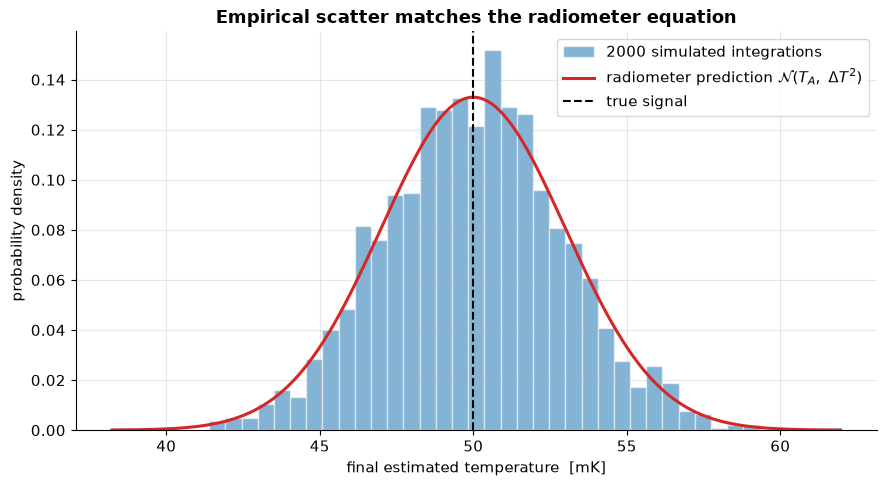

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

# Histogram of the final estimates from the ensemble.
ax.hist(
    final_estimates * 1e3,
    bins=45,
    density=True,
    color="#1f77b4",
    alpha=0.55,
    edgecolor="white",
    label=f"{n_trials} simulated integrations",
)

# Overlay the Gaussian the radiometer equation predicts.
x = np.linspace(final_estimates.min(), final_estimates.max(), 400)
gauss = np.exp(-0.5 * ((x - true_signal) / predicted_sigma) ** 2) / (
    predicted_sigma * np.sqrt(2 * np.pi)
)
ax.plot(
    x * 1e3,
    gauss / 1e3,
    color="#d62728",
    lw=2.2,
    label=r"radiometer prediction $\mathcal{N}(T_A,\ \Delta T^2)$",
)

ax.axvline(true_signal * 1e3, color="k", ls="--", lw=1.5, label="true signal")
ax.set_xlabel("final estimated temperature  [mK]")
ax.set_ylabel("probability density")
ax.set_title("Empirical scatter matches the radiometer equation")
ax.legend()
fig.tight_layout()
plt.show()

The simulated histogram sits squarely under the red Gaussian whose width is set *entirely* by
the radiometer equation — no fitting, no free parameters. The empirical standard deviation
agrees with $\Delta T = T_\mathrm{sys}/\sqrt{B\tau}$ to within about a percent, which is just
the sampling uncertainty of using a finite number of trials. The radiometer equation isn't a
rule of thumb; it is the literal standard deviation of your measurement.

## Why Dicke switched: beating gain drift

There's a catch the radiometer equation quietly assumes: that the receiver **gain is
constant**. It isn't. Amplifiers drift — their gain wanders slowly with temperature and time,
a low-frequency "$1/f$" noise. A slow swell in gain looks exactly like a slow swell in sky
temperature, and no amount of integration removes it: averaging only beats *random* noise, not
a *systematic* drift.

Dicke's fix was disarmingly simple. **Switch** the receiver rapidly between the sky and a
stable reference load at a known temperature, and record only the *difference*. Over one fast
switch cycle the gain is effectively frozen, so when you subtract sky from reference the
common-mode gain wandering **cancels**, leaving only the genuine sky–reference temperature
difference. You pay a modest price — you only look at the sky half the time, costing a factor
of two in sensitivity — but you trade an unbeatable systematic for a beatable one.

The simulation below makes the point. We give the receiver a slow sinusoidal gain drift and
compare a **total-power** measurement (which rides the drift) against a **Dicke-switched**
difference (which is immune to it).

In [10]:
gen = signals.rng(SEED)

T_sys = 30.0
T_ref = 0.0  # reference load matched to the system baseline already present in both arms
T_sky_true = 0.20  # a faint, constant sky signal above the reference, in K
n = 4000
t = np.linspace(0, 200.0, n)  # 200 s of data

# A slow multiplicative gain drift (1/f-like): +/-10% wander over the track.
gain = 1.0 + 0.10 * np.sin(2 * np.pi * t / 130.0) + 0.03 * np.sin(2 * np.pi * t / 23.0)

# Fast thermal noise on every sample.
noise_sky = gen.normal(0.0, 1.5, size=n)
noise_ref = gen.normal(0.0, 1.5, size=n)

# Total-power radiometer: gain multiplies the (sky + system) temperature.
total_power = gain * (T_sys + T_sky_true + noise_sky)

# Dicke-switched: difference of sky and reference, each scaled by the SAME instantaneous gain.
# Both arms share the T_sys baseline, so their difference isolates the sky signal (T_sky_true - T_ref).
sky_arm = gain * (T_sys + T_sky_true + noise_sky)
ref_arm = gain * (T_sys + T_ref + noise_ref)
dicke = sky_arm - ref_arm  # gain cancels in the difference (up to noise)

# Running means to show what each estimator converges to.
tp_running = np.cumsum(total_power) / np.arange(1, n + 1)
dk_running = np.cumsum(dicke) / np.arange(1, n + 1)

print(f"true sky-minus-reference signal: {T_sky_true:.3f} K")
print(
    f"total-power final estimate (minus T_sys): {tp_running[-1] - T_sys:.3f} K  <- biased by drift"
)
print(f"Dicke-switched final estimate:            {dk_running[-1]:.3f} K  <- recovers the truth")

true sky-minus-reference signal: 0.200 K
total-power final estimate (minus T_sys): 0.860 K  <- biased by drift
Dicke-switched final estimate:            0.198 K  <- recovers the truth


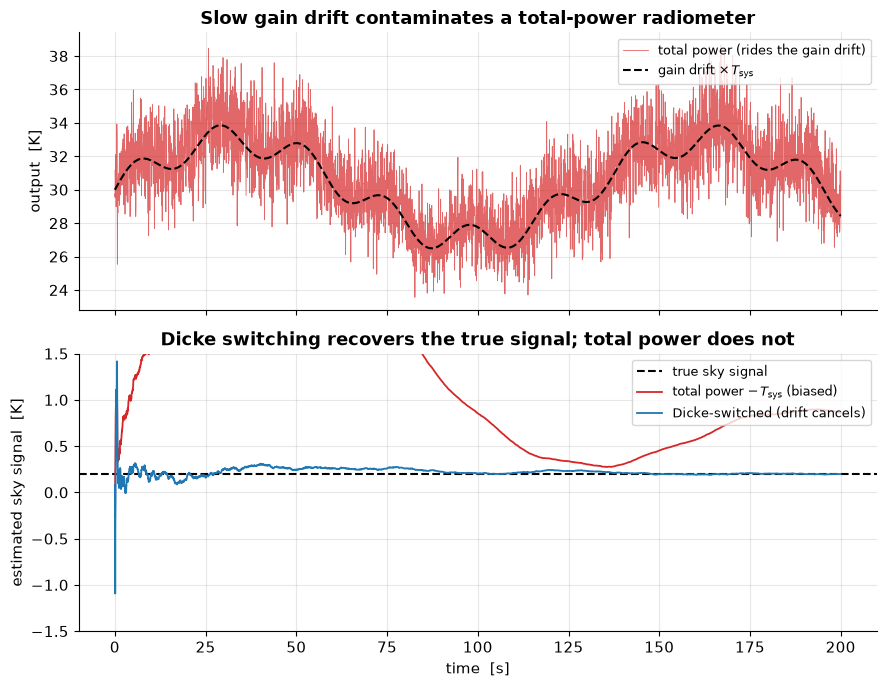

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# Top: the raw streams, showing the gain drift riding on the total-power signal.
ax1.plot(
    t, total_power, color="#d62728", lw=0.6, alpha=0.7, label="total power (rides the gain drift)"
)
ax1.plot(t, T_sys * gain, color="k", lw=1.5, ls="--", label=r"gain drift $\times\,T_\mathrm{sys}$")
ax1.set_ylabel("output  [K]")
ax1.set_title("Slow gain drift contaminates a total-power radiometer")
ax1.legend(loc="upper right", fontsize=9)

# Bottom: the two running estimates of the sky signal.
ax2.axhline(T_sky_true, color="k", ls="--", lw=1.5, label="true sky signal")
ax2.plot(
    t,
    tp_running - T_sys,
    color="#d62728",
    lw=1.3,
    label="total power $-\\,T_\\mathrm{sys}$ (biased)",
)
ax2.plot(t, dk_running, color="#1f77b4", lw=1.3, label="Dicke-switched (drift cancels)")
ax2.set_xlabel("time  [s]")
ax2.set_ylabel("estimated sky signal  [K]")
ax2.set_title("Dicke switching recovers the true signal; total power does not")
ax2.set_ylim(-1.5, 1.5)
ax2.legend(loc="upper right", fontsize=9)

fig.tight_layout()
plt.show()

The red total-power estimate sways with the gain drift and never settles on the truth — a
slow systematic that integration cannot remove. The blue Dicke-switched estimate cancels the
common-mode gain and homes in on the true 0.2 K sky signal. This is the principle behind the
Dicke radiometer, the WMAP and Planck CMB experiments' differential designs, and countless
ground-based receivers. Stability, not just sensitivity, is half the battle.

## Try it yourself

1. **Plan a real observation.** The HI 21 cm line from a faint dwarf galaxy might give an
   antenna temperature of $T_A = 5$ mK against a $T_\mathrm{sys} = 25$ K system in a 10 kHz
   spectral channel. Using `signals.radiometer_sensitivity`, how long must you integrate to
   reach a $5\sigma$ detection ($\Delta T = T_A/5$)? How does that change if you average both
   polarisations? *(Hint: solve $\Delta T = T_\mathrm{sys}/\sqrt{n_\mathrm{pol} B\tau}$ for
   $\tau$.)*

2. **Bandwidth vs. time trade-off.** Suppose you can either double your bandwidth or double
   your integration time. For *continuum* sensitivity, does it matter which you choose? Verify
   numerically with `radiometer_sensitivity`. Then think about *why* you might still prefer one
   over the other in practice (spectral resolution, RFI, system stability).

3. **How many trials to confirm the equation?** Re-run the ensemble test that compares the
   empirical and predicted $\Delta T$, but vary `n_trials` from 50 to 5000. Plot the ratio
   `empirical_sigma / predicted_sigma` against `n_trials`. How quickly does it converge to 1,
   and how does the residual scatter shrink? *(This is itself a $1/\sqrt{N}$ law.)*

4. **Push the Dicke switch.** In the gain-drift simulation, increase the drift amplitude from
   10% to 50%. Does the total-power estimate get worse? Does the Dicke-switched estimate stay
   robust? At what point does the *noise* (not the drift) become the limiting factor again?

<details><summary>Solution — Exercise 1</summary>

Solve the radiometer equation for $\tau$: setting $\Delta T = T_A/5$ in $\Delta T = T_\mathrm{sys}/\sqrt{n_\mathrm{pol} B\tau}$ gives $\tau = (T_\mathrm{sys}/\Delta T)^2 / (n_\mathrm{pol} B)$. Averaging both polarisations halves the required time.

```python
T_sys, B, T_A = 25.0, 10e3, 5e-3   # K, Hz, K
dT_target = T_A / 5                  # 5-sigma detection

tau_1pol = (T_sys / dT_target) ** 2 / (1 * B)
tau_2pol = (T_sys / dT_target) ** 2 / (2 * B)

print(f"target dT (5-sigma) = {dT_target*1e3:.2f} mK")
print(f"single pol: tau = {tau_1pol:.0f} s = {tau_1pol/3600:.2f} h")
print(f"dual   pol: tau = {tau_2pol:.0f} s = {tau_2pol/3600:.2f} h")

# Verify by plugging back into the helper.
print("check 1pol:", signals.radiometer_sensitivity(T_sys, B, tau_1pol))
print("check 2pol:", signals.radiometer_sensitivity(T_sys, B, tau_2pol, n_pol=2))
```

Expected: about $6.25\times10^4$ s ($\approx 17.4$ h) for a single polarisation, halved to $\approx 8.7$ h with both — both yielding $\Delta T = 1.0$ mK, exactly $T_A/5$. **Takeaway:** a 5 mK line against a 25 K system in a narrow 10 kHz channel is genuinely expensive, and using dual polarisation is the cheapest factor-of-two you will ever get.

</details>

<details><summary>Solution — Exercise 2</summary>

Because $\Delta T \propto (B\tau)^{-1/2}$, *continuum* sensitivity depends only on the **product** $B\tau$ — so doubling either one buys exactly the same factor of $1/\sqrt{2}$. The two choices are mathematically identical for broadband sensitivity.

```python
T_sys, B0, tau0 = 30.0, 100e6, 10.0
base    = signals.radiometer_sensitivity(T_sys, B0, tau0)
dbl_B   = signals.radiometer_sensitivity(T_sys, 2 * B0, tau0)
dbl_tau = signals.radiometer_sensitivity(T_sys, B0, 2 * tau0)

print(f"baseline      dT = {base*1e3:.4f} mK")
print(f"double B      dT = {dbl_B*1e3:.4f} mK")
print(f"double tau    dT = {dbl_tau*1e3:.4f} mK")
print(f"identical? {np.isclose(dbl_B, dbl_tau)}   (both = base/sqrt(2))")
```

Expected: doubling $B$ and doubling $\tau$ give the *same* $\Delta T \approx 0.671$ mK, each a factor $\sqrt{2}$ below the 0.949 mK baseline. **But in practice the choice matters:** wider bandwidth costs spectral resolution (bad for line work and harder to flag RFI within the band), while longer integration demands the receiver gain stay stable over the whole track — exactly the drift problem Dicke switching addresses. You trade between the radiometer equation's two knobs according to which systematic you can better tolerate.

</details>

<details><summary>Solution — Exercise 3</summary>

Wrap the ensemble test in a loop over `n_trials` and record the ratio of empirical to predicted $\Delta T$ each time. The ratio is itself an estimate from a finite sample, so its own scatter shrinks as $1/\sqrt{n_\mathrm{trials}}$ — the same square-root law, one level up.

```python
T_sys, B, total_time, true_signal = 30.0, 1e6, 100.0, 0.05
predicted_sigma = signals.radiometer_sensitivity(T_sys, B, total_time)

trial_counts = np.array([50, 100, 200, 500, 1000, 2000, 5000])
ratios = []
for n_trials in trial_counts:
    final_estimates = np.array([
        signals.integrate_noise(T_sys, B, total_time, signal=true_signal,
                                n_samples=1000, seed=s).estimate[-1]
        for s in range(n_trials)
    ])
    ratios.append(final_estimates.std(ddof=1) / predicted_sigma)
ratios = np.array(ratios)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogx(trial_counts, ratios, "o-", color="#1f77b4", label="empirical / predicted")
ax.axhline(1.0, color="k", ls="--", lw=1.5, label="exact agreement")
# The expected 1-sigma scatter of the ratio falls as 1/sqrt(2 n_trials).
ax.fill_between(trial_counts, 1 - 1/np.sqrt(2*trial_counts), 1 + 1/np.sqrt(2*trial_counts),
                color="gray", alpha=0.2, label=r"$\pm 1/\sqrt{2\,n_\mathrm{trials}}$")
ax.set_xlabel("number of trials")
ax.set_ylabel(r"$\sigma_\mathrm{empirical}\,/\,\Delta T_\mathrm{predicted}$")
ax.set_title("The ratio converges to 1 as $1/\\sqrt{n_\\mathrm{trials}}$")
ax.legend()
fig.tight_layout()
plt.show()
```

Expected: the ratio hovers around 1 throughout (roughly 1.06 at 50 trials, settling to within a percent of 1 by a few thousand), and the run-to-run scatter narrows along the grey $\pm 1/\sqrt{2\,n_\mathrm{trials}}$ band. **Takeaway:** confirming the radiometer equation to 1% needs of order a thousand trials — and tightening that estimate ten-fold would cost a hundred-fold more, the same quadratic price the equation itself imposes.

</details>

<details><summary>Solution — Exercise 4</summary>

Re-run the gain-drift simulation with a larger drift amplitude. The total-power estimate scales with the drift and gets badly worse, while the Dicke difference cancels the common-mode gain and stays close to the truth — until the gain swing grows so large that it multiplies the per-sample *noise* difference, at which point the residual noise (not the drift) limits you.

```python
gen = signals.rng(SEED)
T_sys, T_ref, T_sky_true, n = 30.0, 0.0, 0.20, 4000
t = np.linspace(0, 200.0, n)
noise_sky = gen.normal(0.0, 1.5, size=n)
noise_ref = gen.normal(0.0, 1.5, size=n)

for amp in (0.10, 0.50):
    gain = 1.0 + amp * np.sin(2 * np.pi * t / 130.0) + 0.3 * amp * np.sin(2 * np.pi * t / 23.0)
    total_power = gain * (T_sys + T_sky_true + noise_sky)
    dicke = gain * (T_sys + T_sky_true + noise_sky) - gain * (T_sys + T_ref + noise_ref)
    print(f"drift {amp*100:.0f}%:  total power - T_sys = {total_power.mean() - T_sys:+.3f} K   "
          f"Dicke = {dicke.mean():.3f} K  (true {T_sky_true:.2f})")
```

Expected: the total-power bias grows from about +0.86 K at 10% drift to roughly +3.4 K at 50% — integration cannot remove it. The Dicke estimate stays near 0.20 K (about 0.20 K at 10%, ~0.29 K at 50%): the gain still cancels, but the larger gain swing amplifies the sky/reference noise difference, so the residual error is now set by thermal noise rather than the drift. **Takeaway:** Dicke switching converts an unbeatable systematic into a beatable random noise — at the modest cost of looking at the sky only half the time.

</details>

## Recap

- A radio telescope is a **thermometer**: every noise source — receiver, sky, ground, CMB,
  and the astronomical signal — is folded into one **system temperature**
  $T_\mathrm{sys}$, and the target is the small **antenna temperature** $T_A$ riding on top.
- The **radiometer equation**, $\;\Delta T = T_\mathrm{sys}/\sqrt{n_\mathrm{pol}\,B\,\tau}\;$,
  follows directly from averaging $\sim B\tau$ independent samples: sensitivity improves as
  the **square root** of bandwidth $\times$ time. We verified the exact $-1/2$ slope and the
  $\sqrt{2}$ polarisation gain numerically.
- A Monte-Carlo integration showed a faint source **emerging from the noise**, and an
  ensemble of 2000 runs confirmed that the empirical scatter matches the predicted $\Delta T$
  to about a percent — the equation *is* the standard deviation of your measurement.
- **Dicke switching** against a reference load cancels common-mode **gain drift**, the
  systematic that integration alone cannot beat — the idea behind every stable microwave
  radiometer since 1946, including the experiments that mapped the cosmic microwave background.

## What's next

We now know *how well* a receiver can measure a temperature. In **Chapter 4 — Antennas,
Apertures & Receivers** we'll ask where that temperature comes from in the first place: how an
antenna's **collecting area** and **beam** turn an incoming flux density (in janskys!) into an
antenna temperature, what sets $T_\mathrm{sys}$ in real hardware, and how dish size trades off
against the resolution we met in the Airy pattern. The radiometer equation will reappear there
dressed in flux units — as the **System Equivalent Flux Density (SEFD)** — to tell us the
faintest source a given telescope can detect.